ЛАБОРАТОРНАЯ РАБОТА ПО ОБРАБОТКЕ ИЗОБРАЖЕНИЙ #9
 
1. Написать генератор произвольной последовательности рукописных символов
--------------------------------------------------------------------------------
Допустимые символы: ['(', ')', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 't', 'x', 'y', ',', '+', '-', '*']
Сгенерированная последовательность: -,3t+843,,


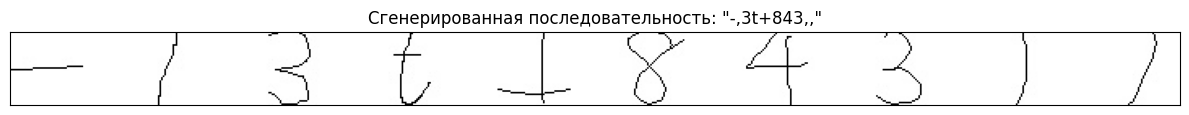




2. Выделение объектов (символов) из изображения последовательности
--------------------------------------------------------------------------------


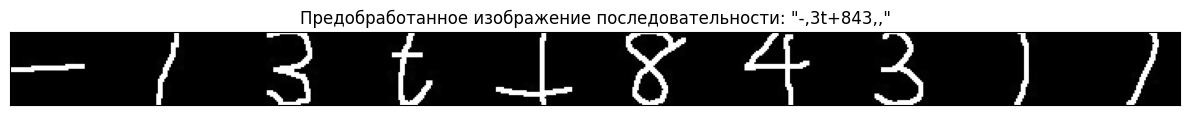

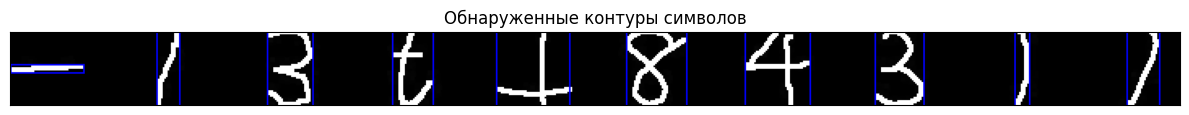

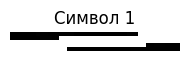

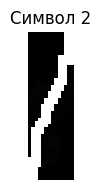

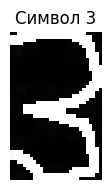

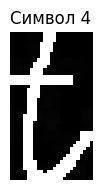

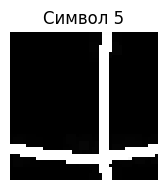

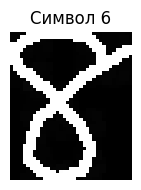

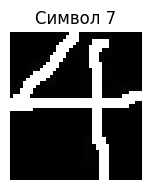

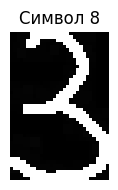

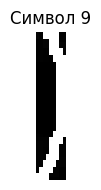

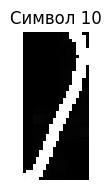

Выделено символов: 10



3. Нормализация размеров символов до 45x45 пикселей
--------------------------------------------------------------------------------


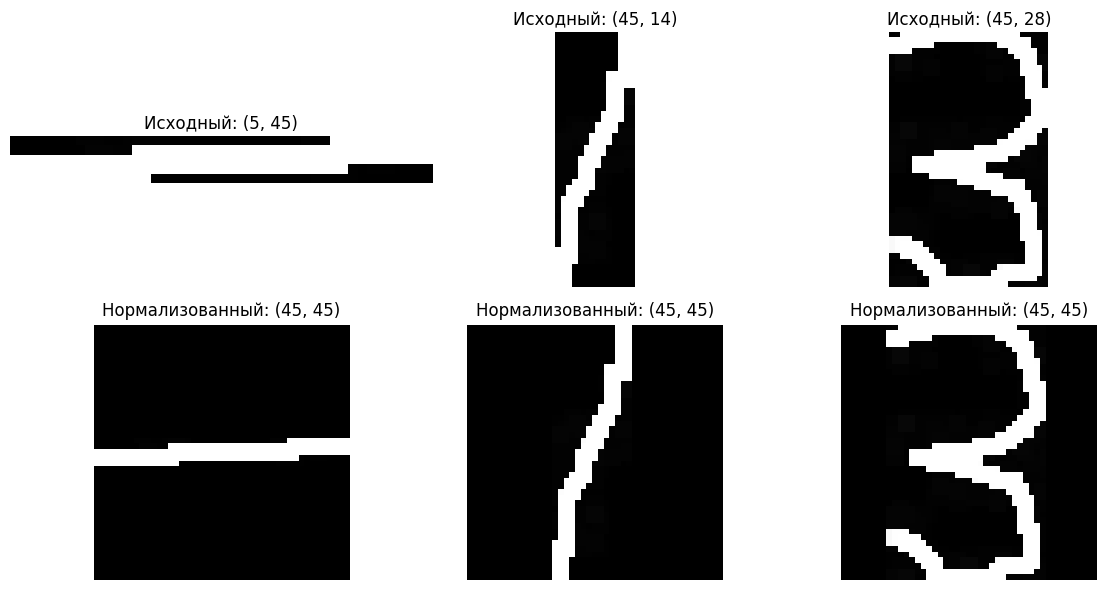




4. Подготовка обучающего набора данных (80% изображений для обучения)
--------------------------------------------------------------------------------
Загружено для обучения: 180225 изображений



5. Обучение классификаторов k-NN с разными значениями k
--------------------------------------------------------------------------------
Модель KNN с k=1 обучена
Модель KNN с k=3 обучена
Модель KNN с k=5 обучена
Модель KNN с k=7 обучена



6. Распознавание символов и оценка точности (accuracy)
--------------------------------------------------------------------------------
Исходная последовательность: '-,3t+843,,'

Модель: KNN с k=1
  Символ 1: предсказан как '-'
  Символ 2: предсказан как '1'
  Символ 3: предсказан как '3'
  Символ 4: предсказан как 't'
  Символ 5: предсказан как '+'
  Символ 6: предсказан как '8'
  Символ 7: предсказан как '4'
  Символ 8: предсказан как '3'
  Символ 9: предсказан как ')'
  Символ 10: предсказан как ','

Распознанная последовательность: '-13t+843),'

Ошиб

In [4]:
import os
import random
import cv2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

print("="*50)
print("ЛАБОРАТОРНАЯ РАБОТА ПО ОБРАБОТКЕ ИЗОБРАЖЕНИЙ #9")
print("="*50)
print(" ")

# Путь к датасету
DATASET_PATH = r"C:\Users\Eseniya\PyCharmMiscProject\Practice_lab9\data"

###1 ЗАДАНИЕ: Написать генератор произвольной последовательности рукописных символов
print("1. Написать генератор произвольной последовательности рукописных символов")
print("-"*80)

class SymbolsSequenceGenerator:
    def __init__(self, dataset_path):
        self.symbols = list(('(', ')', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 't', 'x', 'y', ',', '+', '-', '*'))
        self.dataset_path = dataset_path
        print('Допустимые символы:', self.symbols)

    def get_symbol_image(self, symbol): #Получить случайное изображение символа из валидационной части датасета
        folder_name = symbol if symbol != 'x' else 'X'
        symbol_path = os.path.join(self.dataset_path, folder_name)

        imgs = [i for i in os.listdir(symbol_path)]
        imgs.sort()

        start_ind = int(len(imgs) * 0.8)
        imgs_validation = imgs[start_ind:]

        random_img = random.choice(imgs_validation)
        img_path = os.path.join(symbol_path, random_img)
        img_data = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        return img_data

    def generate_sequence(self, seq_length):  #Сгенерировать случайную последовательность символов
        seq = ''.join(random.choices(self.symbols, k=seq_length))
        imgs = []
        print(f"Сгенерированная последовательность: {seq}")

        for char in seq:
            img = self.get_symbol_image(char)
            if img is not None:
                imgs.append(img)

        return seq, imgs

generator = SymbolsSequenceGenerator(DATASET_PATH)

def create_seq_image(imgs, space=20):  #Создать изображение из последовательности символов с пробелами
    max_height = max(img.shape[0] for img in imgs)
    width = sum(img.shape[1] for img in imgs) + space * (len(imgs) - 1)
    seq_img = np.ones((max_height, width), dtype=np.uint8) * 255

    x_offset = 0
    for img in imgs:
        h, w = img.shape
        y_offset = (max_height - h)
        seq_img[y_offset:y_offset + h, x_offset:x_offset + w] = img
        x_offset += w + space

    return seq_img

seq, imgs = generator.generate_sequence(10)
seq_img = create_seq_image(imgs, 30)

plt.figure(figsize=(12, 4))
plt.imshow(seq_img, cmap='gray')
plt.title(f'Сгенерированная последовательность: "{seq}"')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()
print("\n\n")


###2 ЗАДАНИЕ: Выделение объектов (символов) из изображения последовательности
print("2. Выделение объектов (символов) из изображения последовательности")
print("-"*80)

kernel = np.ones((3, 3), np.uint8)
img_gray = seq_img.copy()
img_gray = cv2.erode(img_gray, kernel, iterations=1)
img_gray = cv2.bitwise_not(img_gray)

# Подготовка базового изображения
base_size = img_gray.shape[0], img_gray.shape[1]
base = np.zeros(base_size, dtype=np.uint8)
base[0:img_gray.shape[0], 0:img_gray.shape[1]] = img_gray
base = cv2.cvtColor(base, cv2.COLOR_GRAY2RGB)
img_rgb = base.copy()

plt.figure(figsize=(12, 4))
plt.imshow(img_rgb)
plt.title(f'Предобработанное изображение последовательности: "{seq}"')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

ret, thresh = cv2.threshold(img_rgb, 127, 255, 0)
thresh = np.uint8(thresh)
contours, h = cv2.findContours(thresh[:, :, 0], cv2.RETR_EXTERNAL, 2)

crops = []
contours_sorted = sorted(contours, key=lambda cnt: cv2.boundingRect(cnt)[0])

for i in range(len(contours_sorted)):
    cnt = contours_sorted[i]
    x, y, w, h = cv2.boundingRect(cnt)

    while w > 45:
        w -= 1

    if w * h > 50:
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 0, 255), 1)
        crops.append([x, y, w, h])

plt.figure(figsize=(12, 4))
plt.imshow(img_rgb)
plt.title(f'Обнаруженные контуры символов')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

# Извлечение отдельных символов
seq_symbols = []
for i in range(len(crops)):
    x, y, w, h = crops[i]
    img_crop = img_gray[y:y + h, x:x + w]
    seq_symbols.append((x, img_crop))

    plt.figure(figsize=(2, 2))
    plt.imshow(img_crop, cmap="gray")
    plt.title(f'Символ {i + 1}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print(f"Выделено символов: {len(seq_symbols)}")
print("\n\n")


###3 ЗАДАНИЕ: Нормализация размеров символов
print("3. Нормализация размеров символов до 45x45 пикселей")
print("-"*80)

def center_and_square_image(img, target_size=45):    #Центрировать изображение и привести к квадратному формату
    h, w = img.shape
    squared = np.zeros((target_size, target_size), dtype=np.uint8)
    x_offset = (target_size - w) // 2
    y_offset = (target_size - h) // 2
    squared[y_offset:y_offset + h, x_offset:x_offset + w] = img
    return squared

normalized_symbols = []
for x, symbol_img in seq_symbols:
    resized_img = center_and_square_image(symbol_img)
    normalized_symbols.append((x, resized_img))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i in range(min(3, len(normalized_symbols))):
    orig_img = seq_symbols[i][1]
    resized_img = normalized_symbols[i][1]

    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(f'Исходный: {orig_img.shape}')
    axes[0, i].axis('off')

    axes[1, i].imshow(resized_img, cmap='gray')
    axes[1, i].set_title(f'Нормализованный: {resized_img.shape}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()
print("\n\n")


###4 ЗАДАНИЕ: Подготовка обучающего набора данных
print("4. Подготовка обучающего набора данных (80% изображений для обучения)")
print("-"*80)

def load_training_data(data_path, symbols_list, training_ratio=0.8):  #Загрузить обучающий набор данных
    training_features = []
    training_labels = []

    for s in symbols_list:
        symbol_path = os.path.join(data_path, s)
        img_list = [f for f in os.listdir(symbol_path) if os.path.isfile(os.path.join(symbol_path, f))]
        img_list.sort()

        split_point = int(len(img_list) * training_ratio)
        training_images = img_list[:split_point]

        for img_file in training_images:
            img_path = os.path.join(symbol_path, img_file)
            img_data = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img_data is not None:
                training_features.append(img_data.flatten())
                label = 'X' if s == 'x' else s
                training_labels.append(label)

    return np.array(training_features), np.array(training_labels)

symbols_set = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', 'times', 't', 'X', 'y', 'w', 'h', '(', ')', ',']
x_train, y_train = load_training_data(DATASET_PATH, symbols_set)
print(f"Загружено для обучения: {len(x_train)} изображений")
print("\n\n")


###5 ЗАДАНИЕ: Обучение классификаторов k-NN с разными значениями k
print("5. Обучение классификаторов k-NN с разными значениями k")
print("-"*80)

neighbor_variants = [1, 3, 5, 7]
knn_models = {}

for n in neighbor_variants:
    classifier = KNeighborsClassifier(n_neighbors=n)
    classifier.fit(x_train, y_train)
    knn_models[n] = classifier
    print(f"Модель KNN с k={n} обучена")

print("\n\n")


###6 ЗАДАНИЕ: Распознавание символов и оценка точности
print("6. Распознавание символов и оценка точности (accuracy)")
print("-"*80)

def predict_symbol(model, img):   #Предсказать символ на изображении
    img = cv2.bitwise_not(img)
    img_flat = img.flatten()
    prediction = model.predict([img_flat])
    return prediction[0]

original_text = seq
print(f"Исходная последовательность: '{original_text}'")
print()

results = {}

for k, model in knn_models.items():
    print(f"{'='*50}")
    print(f"Модель: KNN с k={k}")
    print(f"{'='*50}")

    predicted_symbols = []

    for j, (x, symbol_img) in enumerate(normalized_symbols):
        predicted_char = predict_symbol(model, symbol_img)
        predicted_symbols.append(predicted_char)
        print(f"  Символ {j+1}: предсказан как '{predicted_char}'")

    predicted_text = ''.join(predicted_symbols)
    print(f"\nРаспознанная последовательность: '{predicted_text}'")

    # Вычисление точности
    correct_chars = sum(1 for orig, pred in zip(original_text, predicted_text) if orig == pred)
    total_chars = len(original_text)
    accuracy = correct_chars / total_chars

    if original_text != predicted_text:
        print("\nОшибки распознавания:")
        for idx, (orig_char, pred_char) in enumerate(zip(original_text, predicted_text)):
            if orig_char != pred_char:
                print(f"  Позиция {idx+1}: ожидалось '{orig_char}', получено '{pred_char}'")

    print(f"\nТочность (accuracy): {accuracy:.2%} ({correct_chars}/{total_chars} символов)")
    print()

    results[k] = {
        'predicted_text': predicted_text,
        'accuracy': accuracy,
        'correct_chars': correct_chars,
        'total_chars': total_chars
    }

print(f"{'='*60}")
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print(f"{'='*60}")
print(f"{'k':^5} | {'Accuracy':^10} | {'Верных':^6} | {'Распознано':^30}")
print(f"{'-'*60}")

sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for k, result in sorted_results:
    accuracy_percent = result['accuracy'] * 100
    print(f"{k:^5} | {accuracy_percent:^9.2f}% | {result['correct_chars']:^3}/{result['total_chars']:^2} | '{result['predicted_text']}'")

print(f"{'='*60}")
best_k = sorted_results[0][0]
best_accuracy = sorted_results[0][1]['accuracy']
print(f"Оптимальное значение k: {best_k} (точность: {best_accuracy:.2%})")